# Problem statement — a terrain change the gait does not know about

A quadruped walks with a central-pattern-generator (CPG) gait that was tuned to
be optimal on **flat** ground. **Five metres in**, it encounters a **15°
incline**. The flat-optimal parameters are no longer a good fit for the incline,
so the robot's behaviour degrades (it leans, slows, and may topple).

This notebook demonstrates the core problem and the signal our method uses to
**detect** it:

1. Run the robot for **40 s** on terrain that is flat for the first 5 m and then
   rises at 15°, holding the **flat-optimal** CPG parameters throughout.
2. Alongside the controller, run a **MARX-EFE** agent as a passive monitor. It
   learns a Multivariate Auto-Regressive eXogenous model of the body dynamics
   online and, every control step, reports its **prediction error**: the
   **cross-entropy between its one-step posterior predictive
   `p(y_k | u_k, D_{k-1})` and a goal prior** over stable on-target walking.
   This is the goal-directed term of the expected free energy — it rises when
   the predicted body state departs from stable, on-goal locomotion.
3. Use that signal as an **event trigger**: when the cross-entropy exceeds
   `K = 2` for at least **2 consecutive steps**, switch the CPG parameters to
   the **slope-optimal** ones.
4. Compare the two resulting trajectories — *hold flat-optimal* vs.
   *switch on the trigger* — in terms of **stability**.

The monitor and the cross-entropy statistic are exactly those used in
`experiment-eventtrigger` (`methods.marxefe_optimizer.MARXAgent.crossentropy`,
fed through `build_marx_agent`); this notebook is the single-trajectory,
pedagogical version of that experiment.

## 1. Configuration

We reuse the repository's simulation and model code directly:

- `methods.marxefe_optimizer`: `build_marx_agent`, the `JointCPG` controller,
  `load_environment` / `load_robot`, `extract_observation`, and the
  `MARXAgent.crossentropy` prediction-error statistic.
- `methods.terrain`: the sloped heightfield (flat until `slope_start_y`, then a
  15° ramp).

The two CPG parameter sets are the pre-computed per-terrain optima:
`experiment-flat/results/selected_params.json` (flat-optimal) and
`experiment-sloped/results/selected_params.json` (slope-optimal).

In [14]:
import os, sys, json
import numpy as np
import matplotlib.pyplot as plt

# --- locate the repository root (the folder that contains `methods/`) ---
_here = os.getcwd()
REPO = _here
while REPO != os.path.dirname(REPO):
    if os.path.isdir(os.path.join(REPO, "methods")):
        break
    REPO = os.path.dirname(REPO)
if REPO not in sys.path:
    sys.path.insert(0, REPO)
print("repo root:", REPO)

# --- experiment constants -----------------------------------------------------
DT          = 0.01        # control/sim timestep [s]
DURATION      = 40.0      # total trial length [s]
SLOPE_START_Y = 5.0       # the robot meets the 15 deg incline 5 m into the walk
SLOPE_DEG     = 10.0      # incline angle [deg]
N_COLS      = 1600        # heightfield forward extent (+/- 40 m) for a long rollout
SEED        = 0           # initial joint-angle jitter seed (across-seed variability)
TARGET_VX   = 0.5         # forward-speed target v* [m/s]

# --- prediction-error monitor (MARX-EFE) -------------------------------------
# Goal prior over STABLE on-target walking: velocity loose, attitude tight, and
# roll (lateral tipping) tighter than pitch (which carries a benign incline
# offset). These are the calibrated stability-goal stds from experiment-eventtrigger.
MON_VEL_STD   = 1.0       # std on vx, vy [m/s]
MON_PITCH_DEG = 20.0      # std on pitch (forward tilt) [deg]  -> tolerates slope offset
MON_ROLL_DEG  = 6.0       # std on roll  (lateral bank) [deg]  -> lateral stability, tight
FORGETTING    = 0.995     # exponential forgetting so flat->slope drift is tracked
WARMUP_UPDATES = 150      # steps before the model is trusted enough to report error
EMA_ALPHA     = 0.08      # smoothing of the raw cross-entropy (units unchanged)
ARM_TIME      = 2.5       # earliest allowed trigger [s] (after warm-up settles)

# --- event trigger ------------------------------------------------------------
K             = 0.5       # threshold on the (EMA-smoothed) raw goal cross-entropy
PERSIST_STEPS = 2         # consecutive steps above K before firing
SWITCH_RAMP   = 1        # steps to ramp the new parameters in (0.3 s), avoids chatter

# --- CPG parameter sets -------------------------------------------------------
with open(os.path.join(REPO, "experiment-flat",   "results", "selected_params.json")) as f:
    PARAMS_FLAT = np.array(json.load(f)["params"], float)
with open(os.path.join(REPO, "experiment-sloped", "results", "selected_params.json")) as f:
    PARAMS_SLOPE = np.array(json.load(f)["params"], float)

PARAM_NAMES = ["coupling_gain", "w_swing", "w_stance", "F_FAST",
               "STOP_GAIN", "hip_amp", "knee_amp", "b"]
print("flat-optimal  :", np.round(PARAMS_FLAT, 3))
print("slope-optimal :", np.round(PARAMS_SLOPE, 3))

repo root: /home/synd/Wouter/Onderzoek/Projecten/tue/cpg-agent/RAL2026-CPG-ActInf
flat-optimal  : [ 9.357 10.    23.72  50.787  0.5    0.1    0.5    2.52 ]
slope-optimal : [12.    25.    25.    60.     0.188  0.1    0.5   10.   ]


## 2. One monitored episode

`run_episode_monitored` runs a single open-loop CPG bout and, in lock-step,
drives the MARX-EFE monitor. Each control step it:

1. forms the regressor `x_k` from the AR buffers and the **currently applied**
   CPG parameters (the control input `u_k`);
2. reads off the **goal cross-entropy** `agent.crossentropy(x_k)` — the
   prediction error (0 during the first `WARMUP_UPDATES` steps, while the model
   has too little data to be trusted);
3. steps the `JointCPG` and the physics, extracts the new observation
   `y_k = [vx, vy, pitch, roll]`, and assimilates it with `agent.update`;
4. checks the event trigger on the EMA-smoothed cross-entropy.

If `switch_on_trigger=True`, the moment the trigger fires the applied parameters
are **ramped** from the flat-optimal set to `params_slope` over `SWITCH_RAMP`
steps. With `switch_on_trigger=False` the flat-optimal set is held for the whole
40 s. The two runs share the same seed/terrain, so their pre-trigger prefixes
are identical and the trigger fires at the same step.

Fall detection is **terrain-relative** (height above the local ground, plus an
upright check), since the absolute-height test is blind once the robot climbs.

In [15]:
import pybullet as pyb
from methods import terrain
from methods.marxefe_optimizer import (build_marx_agent, JointCPG,
                                       load_environment, load_robot,
                                       extract_observation)

DEFAULT_ORI = [0.0, 0.5, 0.5, 0.0]
LEG_NAMES   = ["FL", "FR", "RL", "RR"]
JITTER_STD  = 0.002


def _reset_with_jitter(p, robot, seed):
    """Reset to the stance pose and settle 1 s, with a seeded jitter on the
    initial joint angles (identical to methods.episode / experiment-eventtrigger)."""
    rng = np.random.default_rng(10_000 + int(seed))
    jit = rng.normal(0.0, JITTER_STD, size=12)
    p.resetBasePositionAndOrientation(robot, [0.0, 0.0, 0.55], DEFAULT_ORI)
    p.resetBaseVelocity(robot, [0, 0, 0], [0, 0, 0])
    abd, hip, knee = [0, 4, 8, 12], [1, 5, 9, 13], [2, 6, 10, 14]
    for i, jid in enumerate(abd):
        p.resetJointState(robot, jid, 0.0 + jit[i])
    for i, jid in enumerate(hip):
        p.resetJointState(robot, jid, 0.05 + jit[4 + i])
    for i, jid in enumerate(knee):
        p.resetJointState(robot, jid, -0.6 + jit[8 + i])
    for _ in range(int(1.0 / DT)):
        for jid in abd:
            p.setJointMotorControl2(robot, jid, p.POSITION_CONTROL,
                                    targetPosition=0.0, force=500)
        for jid in hip:
            p.setJointMotorControl2(robot, jid, p.POSITION_CONTROL, 0.25)
        for jid in knee:
            p.setJointMotorControl2(robot, jid, p.POSITION_CONTROL, -1.0)
        p.stepSimulation()
    return JointCPG(n_legs=4)


def _build_monitor():
    """MARX-EFE agent used purely as a prediction-error monitor."""
    np.random.seed(0)                       # deterministic tiny prior mean
    return build_marx_agent(
        target_velocity=TARGET_VX,
        goal_prior_std=(MON_VEL_STD, MON_VEL_STD,
                        np.deg2rad(MON_PITCH_DEG), np.deg2rad(MON_ROLL_DEG)),
        forgetting=FORGETTING)


def run_episode_monitored(slope_start_y, params_flat, params_slope=None,
                          switch_on_trigger=False, seed=SEED, duration=DURATION,
                          slope_deg=SLOPE_DEG):
    """Run one 40-s bout on a terrain that is flat until `slope_start_y` then
    ramps at `slope_deg`, holding `params_flat` (optionally switching to
    `params_slope` when the MARX-EFE cross-entropy trigger fires). Returns a log
    dict with the prediction-error signal, attitude, and the trigger/switch step."""
    p = pyb
    terrain.TERRAIN_CONFIG = {"kind": "sloped", "slope_deg": float(slope_deg),
                              "slope_start_y": float(slope_start_y), "n_cols": N_COLS}
    load_environment(DT, use_gui=False)
    robot, _, joint_IDs_full, _, feet = load_robot(p)
    cpg   = _reset_with_jitter(p, robot, seed)
    agent = _build_monitor()

    n_steps  = int(round(duration / DT))
    tan_s    = np.tan(np.deg2rad(slope_deg))
    keys = ["t", "x", "y", "z", "vx", "vy", "roll", "pitch",
            "ce_raw", "ce_ema", "clear_height"]
    log = {k: np.zeros(n_steps) for k in keys}
    applied_log = np.zeros((8, n_steps))

    y_k, base_pos, base_ori = extract_observation(p, robot, DEFAULT_ORI)
    ema, above = 0.0, 0
    fired, fire_step = False, None
    # switch ramp state (only used when switch_on_trigger)
    seg_start = np.asarray(params_flat, float).copy()
    seg_anchor, seg_ramp = 0, 1
    fell, fall_step = False, None

    for k in range(n_steps):
        t = k * DT

        # applied CPG parameters this step
        if switch_on_trigger and fired:
            frac = min(1.0, (k - seg_anchor) / seg_ramp)
            applied = seg_start + frac * (np.asarray(params_slope, float) - seg_start)
        else:
            applied = np.asarray(params_flat, float)

        # (1-2) prediction error BEFORE assimilating y_k: cross-entropy of the
        # one-step posterior predictive under the current control + AR buffers.
        c = 0.0
        if agent.n_updates > WARMUP_UPDATES:
            ubuf = agent.backshift(agent.ubuffer, applied)
            x_k  = np.concatenate([ubuf.flatten(), agent.ybuffer.flatten()])
            try:
                c = float(agent.crossentropy(x_k))
            except Exception:
                c = 0.0

        # (3) CPG -> joints -> physics
        raw = np.array([int(len(p.getContactPoints(bodyA=0, bodyB=robot,
                        linkIndexA=-1, linkIndexB=feet[j])) > 0) for j in range(4)])
        hips, knees = cpg.step(applied, raw, DT)
        for j in range(4):
            abd, hip, kn = joint_IDs_full[LEG_NAMES[j]]
            p.setJointMotorControl2(robot, abd, p.POSITION_CONTROL,
                                    targetPosition=0.0, force=500)
            p.setJointMotorControl2(robot, hip, p.POSITION_CONTROL, hips[j])
            p.setJointMotorControl2(robot, kn,  p.POSITION_CONTROL, knees[j])
        p.stepSimulation()

        y_new, base_pos, base_ori = extract_observation(p, robot, DEFAULT_ORI)
        vel, _ = p.getBaseVelocity(robot)
        pitch, roll, _ = p.getEulerFromQuaternion(base_ori)   # physical convention

        agent.update(y_new, applied)                          # assimilate
        ema = c if k == 0 else (1 - EMA_ALPHA) * ema + EMA_ALPHA * c

        ground_z = tan_s * max(0.0, base_pos[1] - slope_start_y)
        clear    = base_pos[2] - ground_z

        log["t"][k], log["x"][k], log["y"][k], log["z"][k] = t, base_pos[0], base_pos[1], base_pos[2]
        log["vx"][k], log["vy"][k] = vel[1], vel[0]
        log["roll"][k], log["pitch"][k] = roll, pitch
        log["ce_raw"][k], log["ce_ema"][k], log["clear_height"][k] = c, ema, clear
        applied_log[:, k] = applied

        # (4) event trigger on the EMA-smoothed raw cross-entropy
        if (not fired) and t >= ARM_TIME:
            above = above + 1 if ema > K else 0
            if above >= PERSIST_STEPS:
                fired, fire_step = True, k
                if switch_on_trigger:
                    seg_start  = applied.copy()
                    seg_anchor = k
                    seg_ramp   = SWITCH_RAMP

        # terrain-relative fall check
        upright = np.dot([0, 0, 1], p.getMatrixFromQuaternion(base_ori)[6:])
        if upright < 0.3 or clear < 0.25:
            fell, fall_step = True, k
            for kk in keys:
                log[kk] = log[kk][:k + 1]
            applied_log = applied_log[:, :k + 1]
            break
        y_k = y_new

    p.disconnect()
    # step at which the robot first crosses onto the incline (slope onset)
    reached = np.nonzero(log["y"] >= slope_start_y)[0]
    log["onset_step"] = int(reached[0]) if len(reached) else None
    log["applied"]    = applied_log
    log["fell"]       = fell
    log["fall_step"]  = fall_step
    log["fire_step"]  = fire_step
    log["slope_start_y"] = slope_start_y
    return log


## 3. Run A — hold the flat-optimal gait through the slope

The terrain is flat until `SLOPE_START_Y = 5 m`, then ramps up at 15°. At the
flat-optimal cruising speed (~0.5 m/s) the robot reaches the incline roughly 10 s
in; the exact **slope-onset** time is read off each run from when the base first
crosses 5 m. Run A is the baseline: the robot never adapts. We record its
prediction-error signal so we can both *visualise the problem* and see where the
trigger fires.

In [16]:
runA = run_episode_monitored(slope_start_y=SLOPE_START_Y, params_flat=PARAMS_FLAT,
                             switch_on_trigger=False, duration=DURATION)
onsetA = runA["onset_step"]
print("slope onset     :", "not reached" if onsetA is None
      else f"step {onsetA} (t={onsetA*DT:.2f}s, y=5 m)")
print("fell            :", runA["fell"],
      "" if not runA["fell"] else f"(at t={runA['fall_step']*DT:.2f}s)")
print("trigger step    :", runA["fire_step"],
      "" if runA["fire_step"] is None else f"(t={runA['fire_step']*DT:.2f}s)")
print("duration reached:", f"{len(runA['t'])*DT:.2f}s / {DURATION:.0f}s")

slope onset     : step 987 (t=9.87s, y=5 m)
fell            : True (at t=36.41s)
trigger step    : 1063 (t=10.63s)
duration reached: 36.42s / 40s


## 4. The prediction-error signal over time

The MARX-EFE goal cross-entropy (raw, and EMA-smoothed) for the *hold* run. It
sits at a low, steady level while the gait walks the flat prefix, then climbs
once the robot reaches the incline (5 m in) — the model's predicted body state
can no longer be reconciled with the stable-walking goal prior. The `K = 2` line
and the `≥ 2`-step persistence rule define the event trigger.

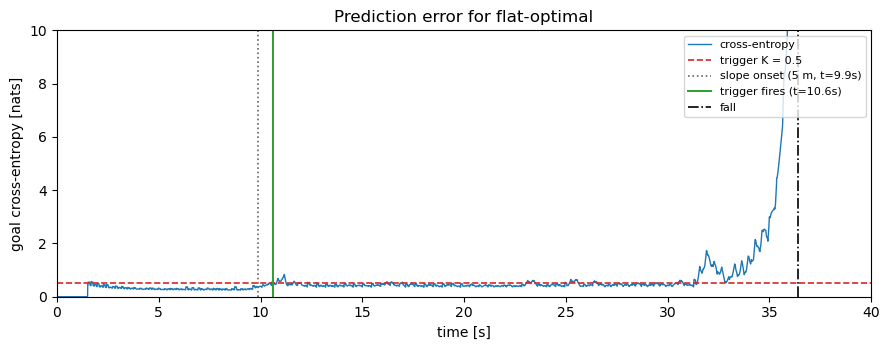

cross-entropy on flat walking (3s-onset): mean 0.295, max 0.363
cross-entropy after slope onset (>9.9s): mean 1.085, max 49.314


In [21]:
def _onset_t(log):
    return None if log["onset_step"] is None else log["onset_step"] * DT

def plot_prediction_error(log, ax=None, title="", showEMA=False):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 3.6))
    t = log["t"]
    if showEMA:
        ax.plot(t, log["ce_raw"], lw=0.8, alpha=0.35, color="tab:blue", label="raw cross-entropy")
        ax.plot(t, log["ce_ema"], lw=1.8, color="tab:blue", label="EMA cross-entropy")
    else:
        ax.plot(t, log["ce_raw"], lw=1, color="tab:blue", label="cross-entropy")
    ax.axhline(K, color="tab:red", ls="--", lw=1.2, label=f"trigger K = {K:g}")
    ot = _onset_t(log)
    if ot is not None:
        ax.axvline(ot, color="0.4", ls=":", lw=1.2,
                   label=f"slope onset (5 m, t={ot:.1f}s)")
    if log["fire_step"] is not None:
        ax.axvline(log["fire_step"] * DT, color="tab:green", ls="-", lw=1.4,
                   label=f"trigger fires (t={log['fire_step']*DT:.1f}s)")
    if log["fell"]:
        ax.axvline(log["fall_step"] * DT, color="k", ls="-.", lw=1.2, label="fall")
    ax.set_xlabel("time [s]"); 
    ax.set_ylabel("goal cross-entropy [nats]")
    ax.set_xlim(0, DURATION); 
    ax.set_ylim(0,10);
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8, ncol=1)
    return ax

plot_prediction_error(runA, title="Prediction error for flat-optimal")
plt.tight_layout(); plt.show()

# report the actual scale so K can be judged / retuned
ot = _onset_t(runA)
flat_win = (runA["t"] >= 3.0) & (runA["t"] < ot)         # settled flat walking
print(f"cross-entropy on flat walking (3s-onset): mean {runA['ce_ema'][flat_win].mean():.3f}, "
      f"max {runA['ce_ema'][flat_win].max():.3f}")
post = runA["t"] >= ot
if post.any():
    print(f"cross-entropy after slope onset (>{ot:.1f}s): mean {runA['ce_ema'][post].mean():.3f}, "
          f"max {runA['ce_ema'][post].max():.3f}")

## 5. Run B — switch to the slope-optimal gait on the trigger

Same terrain and seed, but now the moment the cross-entropy trigger fires the
CPG parameters are ramped to the **slope-optimal** set. Because the pre-trigger
prefix is identical to Run A, the trigger fires at the same step; the two runs
diverge only from that point on.

trigger/switch step: 1063 (t=10.63s)
fell               : False 
duration reached   : 40.00s / 40s


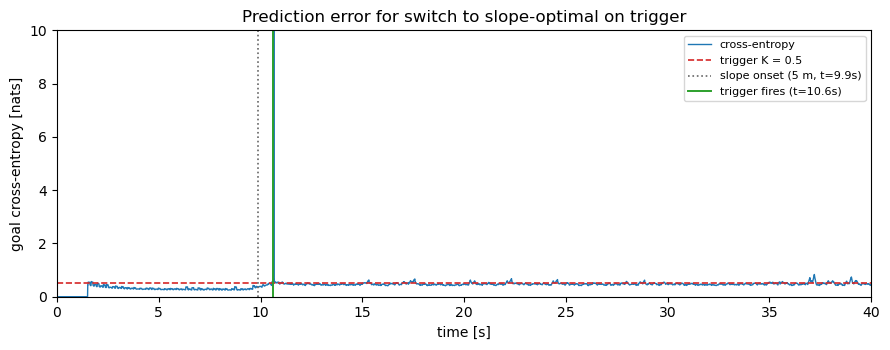

In [22]:
runB = run_episode_monitored(slope_start_y=SLOPE_START_Y, params_flat=PARAMS_FLAT,
                             params_slope=PARAMS_SLOPE, switch_on_trigger=True,
                             duration=DURATION)
print("trigger/switch step:", runB["fire_step"],
      "" if runB["fire_step"] is None else f"(t={runB['fire_step']*DT:.2f}s)")
print("fell               :", runB["fell"],
      "" if not runB["fell"] else f"(at t={runB['fall_step']*DT:.2f}s)")
print("duration reached   :", f"{len(runB['t'])*DT:.2f}s / {DURATION:.0f}s")

fig, ax = plt.subplots(figsize=(9, 3.6))
plot_prediction_error(runB, ax=ax,
                      title="Prediction error for switch to slope-optimal on trigger")
plt.tight_layout(); plt.show()

## 6. Stability comparison — hold vs. switch

We compare the two trajectories with the paper's stability criterion. Attitude
is low-pass filtered (0.5 s moving average) so the gait's rhythmic stride
rocking is free, and only sustained **lateral roll** and **within-window pitch
drift** are penalised. We report, over the **post-slope** window (from the
slope-onset step, i.e. `y > 5 m`):

- RMS low-passed **roll** and detrended **pitch** [deg] — lower is steadier;
- combined attitude RMS and whether the robot **fell**;
- forward distance covered and minimum ground clearance.

The stability score `V = min(mean(vx)/v*, 1) − (RMS roll + RMS pitch)/10` is the
per-terrain oracle criterion from `methods.oracle_fit.score_V`.

In [23]:
def _lowpass(x, w=50):
    x = np.asarray(x, float)
    if len(x) < 2:
        return x
    w = min(w, len(x))
    c = np.concatenate([[0.0], np.cumsum(x)])
    out = np.empty_like(x)
    for i in range(len(x)):
        a, b = max(0, i - w + 1), i + 1
        out[i] = (c[b] - c[a]) / (b - a)
    return out

def stability_report(log):
    """Post-slope-onset stability summary for one run."""
    t = log["t"]
    onset_t = 0.0 if log["onset_step"] is None else log["onset_step"] * DT
    m = t >= onset_t                     # analysis window: on/after the incline
    roll, pitch, vx = log["roll"][m], log["pitch"][m], log["vx"][m]
    if len(roll) < 20:
        return dict(rms_roll=np.nan, rms_pitch=np.nan, combined=np.nan,
                    V=-2.0, fell=log["fell"], fwd=np.nan, min_clear=np.nan)
    lp_roll  = _lowpass(roll)
    lp_pitch = _lowpass(pitch)
    rms_roll  = np.rad2deg(np.sqrt(np.mean(lp_roll ** 2)))
    rms_pitch = np.rad2deg(np.sqrt(np.mean((lp_pitch - np.median(lp_pitch)) ** 2)))
    combined  = np.sqrt(rms_roll ** 2 + rms_pitch ** 2)
    r_v = min(max(float(np.mean(vx)), 0.0) / TARGET_VX, 1.0)
    V   = -2.0 if log["fell"] else r_v - (rms_roll + rms_pitch) / 10.0
    fwd = float(log["y"][-1] - log["y"][np.argmax(m)])
    return dict(rms_roll=rms_roll, rms_pitch=rms_pitch, combined=combined,
                V=V, fell=log["fell"], fwd=fwd,
                min_clear=float(np.min(log["clear_height"][m])))

repA, repB = stability_report(runA), stability_report(runB)
hdr = f"{'metric':<28}{'A: hold flat':>16}{'B: switch':>16}"
print(hdr); print("-" * len(hdr))
def _fmt(v): return "FELL" if v is True else ("-" if v is False else f"{v:8.3f}")
for key, lab in [("fell", "fell?"),
                 ("rms_roll",  "RMS roll [deg]"),
                 ("rms_pitch", "RMS pitch (detrended) [deg]"),
                 ("combined",  "combined attitude RMS [deg]"),
                 ("V",         "stability score V"),
                 ("fwd",       "forward distance on slope [m]"),
                 ("min_clear", "min ground clearance [m]")]:
    print(f"{lab:<28}{_fmt(repA[key]):>16}{_fmt(repB[key]):>16}")


metric                          A: hold flat       B: switch
------------------------------------------------------------
fell?                                   FELL               -
RMS roll [deg]                         5.761           0.833
RMS pitch (detrended) [deg]            1.308           0.691
combined attitude RMS [deg]            5.908           1.082
stability score V                     -2.000           0.848
forward distance on slope [m]          10.803          23.064
min ground clearance [m]               0.314           0.378


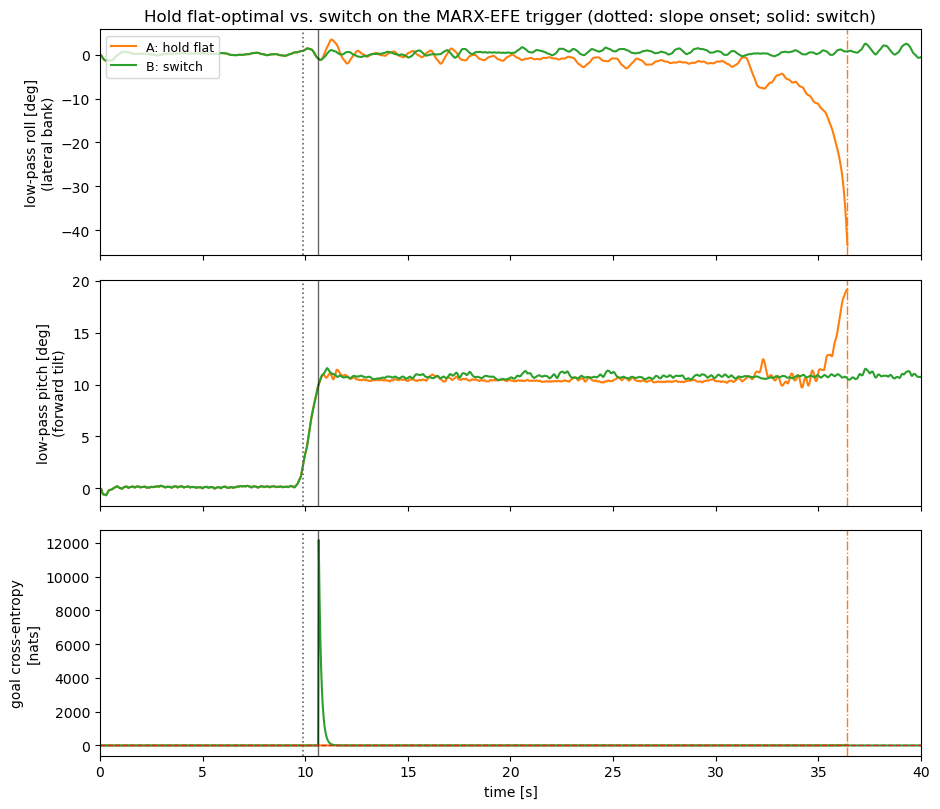

In [24]:
# Side-by-side attitude / clearance / prediction-error trajectories.
fig, axs = plt.subplots(3, 1, figsize=(9.5, 8.2), sharex=True)

for lab, log, col in [("A: hold flat", runA, "tab:orange"),
                      ("B: switch",    runB, "tab:green")]:
    axs[0].plot(log["t"], np.rad2deg(_lowpass(log["roll"])),  color=col, label=lab)
    axs[1].plot(log["t"], np.rad2deg(_lowpass(log["pitch"])), color=col, label=lab)
    axs[2].plot(log["t"], log["ce_ema"], color=col, label=lab)
    if log["fell"]:
        for a in axs:
            a.axvline(log["fall_step"] * DT, color=col, ls="-.", lw=1.0)

fire = runB["fire_step"]
onset_t = _onset_t(runA)
for a in axs:
    if onset_t is not None:
        a.axvline(onset_t, color="0.4", ls=":", lw=1.2)
    if fire is not None:
        a.axvline(fire * DT, color="k", ls="-", lw=1.0, alpha=0.6)
axs[0].set_ylabel("low-pass roll [deg]\n(lateral bank)")
axs[1].set_ylabel("low-pass pitch [deg]\n(forward tilt)")
axs[2].set_ylabel("goal cross-entropy\n[nats]")
axs[2].axhline(K, color="tab:red", ls="--", lw=1.0)
axs[2].set_xlabel("time [s]")
axs[0].set_title("Hold flat-optimal vs. switch on the MARX-EFE trigger "
                 "(dotted: slope onset; solid: switch)")
axs[0].legend(loc="upper left", fontsize=9)
axs[0].set_xlim(0, DURATION)
plt.tight_layout(); plt.show()